In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score



In [2]:
df=pd.read_csv("C:/Users/harma/Desktop/Financial Sample.csv")

In [3]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,1618.5,$3.00,$20.00,"$32,370.00",₹ 0.00,"$32,370.00","$16,185.00","$16,185.00",01-01-2014,1,January,2014
1,Government,Germany,Carretera,None,1321.0,$3.00,$20.00,"$26,420.00",₹ 0.00,"$26,420.00","$13,210.00","$13,210.00",01-01-2014,1,January,2014
2,Midmarket,France,Carretera,None,2178.0,$3.00,$15.00,"$32,670.00",₹ 0.00,"$32,670.00","$21,780.00","$10,890.00",01-06-2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888.0,$3.00,$15.00,"$13,320.00",₹ 0.00,"$13,320.00","$8,880.00","$4,440.00",01-06-2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.0,$3.00,$15.00,"$37,050.00",₹ 0.00,"$37,050.00","$24,700.00","$12,350.00",01-06-2014,6,June,2014


In [37]:
df.columns

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='object')

In [5]:
# Eliminating the white spaces 
df.columns = df.columns.str.strip()

 

In [6]:
df.columns

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='object')

In [7]:
df.dtypes

Segment                 object
Country                 object
Product                 object
Discount Band           object
Units Sold             float64
Manufacturing Price     object
Sale Price              object
Gross Sales             object
Discounts               object
Sales                   object
COGS                    object
Profit                  object
Date                    object
Month Number             int64
Month Name              object
Year                     int64
dtype: object

In [8]:
# Changing the Datatypes 
num_col= ['Manufacturing Price','Sale Price','Gross Sales','Discounts','Sales','COGS','Profit']
for col in num_col:
    df[col] = df[col].astype(str)  # Convert to string if not already
    df[col] = df[col].replace({'\$': '', '₹': '', ',': ''}, regex=True)  # Remove currency symbols and commas
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric, replacing errors with NaN



In [9]:
# Changing data types to datatime 
df['Date'] = pd.to_datetime(df['Date'],errors='coerce')

In [10]:
# Changing  Data type to category 
Cat_col = ['Segment','Country','Product','Discount Band']
for col in Cat_col:
    df[col]=df[col].astype('category')

In [11]:
# reviewing the datatype 
df.dtypes

Segment                      category
Country                      category
Product                      category
Discount Band                category
Units Sold                    float64
Manufacturing Price           float64
Sale Price                    float64
Gross Sales                   float64
Discounts                     float64
Sales                         float64
COGS                          float64
Profit                        float64
Date                   datetime64[ns]
Month Number                    int64
Month Name                     object
Year                            int64
dtype: object

In [12]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,0.0,32670.0,21780.0,10890.0,2014-01-06,6,June,2014
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,0.0,13320.0,8880.0,4440.0,2014-01-06,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,0.0,37050.0,24700.0,12350.0,2014-01-06,6,June,2014


In [13]:
# Checking for null values 
df.isnull().sum()

Segment                 0
Country                 0
Product                 0
Discount Band           0
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
Sales                   0
COGS                    0
Profit                 63
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64

In [14]:
#filling the null values with 0
df['Profit'] = df['Profit'].fillna(0)

In [15]:
df.isnull().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

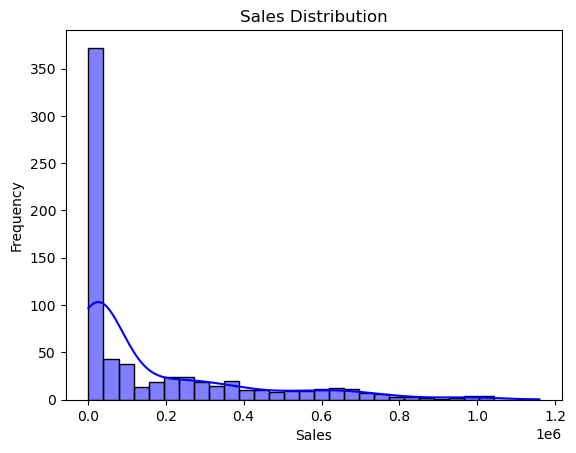

In [16]:
# Plotting histogram for Sales
sns.histplot(df['Sales'], bins=30, kde=True, color='blue')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()


<Axes: xlabel='Profit'>

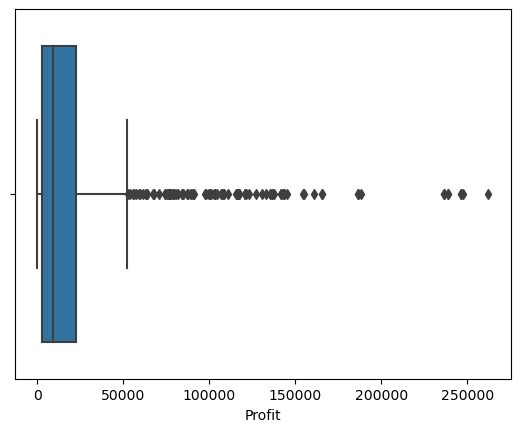

In [17]:
sns.boxplot(x=df['Profit'])


<Axes: xlabel='Discounts', ylabel='Density'>

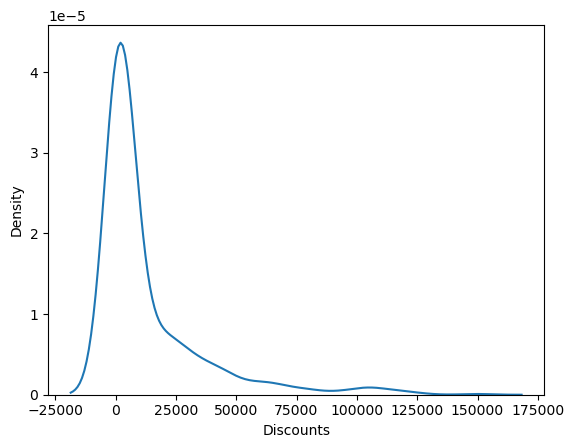

In [18]:
# Kernel Density Estimate (kDE) to understand the Distribution of Discounts 
sns.kdeplot(df['Discounts'])


In [19]:
# Correlation Matrix to Understand the relationships between Variable 
correlation_matrix = df[['Units Sold', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit']].corr()


<Axes: >

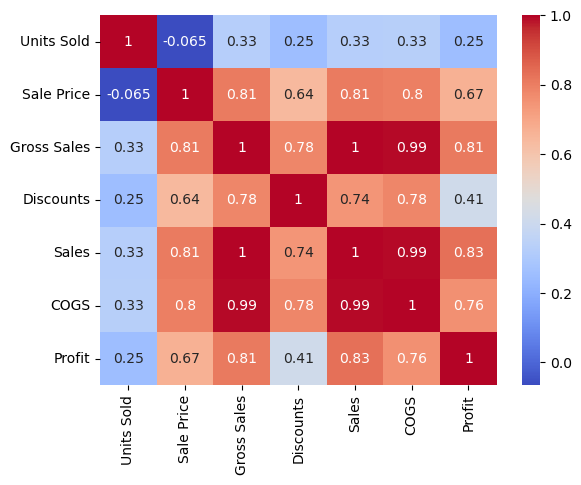

In [20]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')


In [21]:

# Checking For Outliers 

In [22]:
z_scores = np.abs((df['Profit'] - df['Profit'].mean()) / df['Profit'].std())
outliers = df[z_scores > 3]


In [23]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Profit'] < (Q1 - 1.5 * IQR)) | (df['Profit'] > (Q3 + 1.5 * IQR))]


<Axes: xlabel='Segment', ylabel='Sales'>

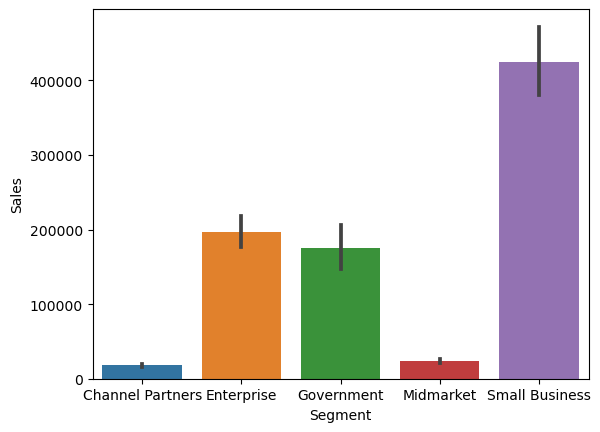

In [24]:
# Total Sales By Segments 
sns.barplot(x='Segment', y='Sales', data=df)


<Axes: xlabel='Country', ylabel='Profit'>

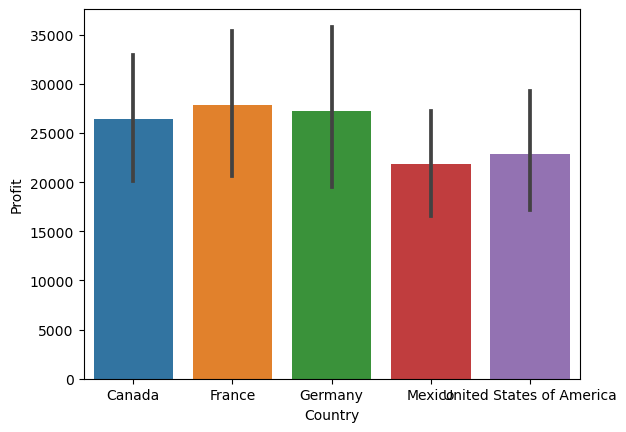

In [25]:
# Total Profit By Country 
sns.barplot(x='Country', y='Profit', data=df)


<Axes: xlabel='Month Name'>

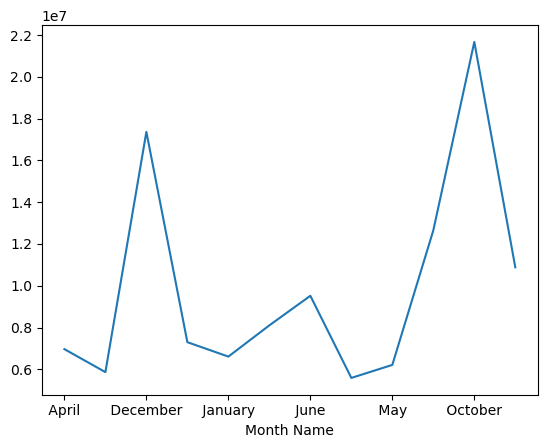

In [26]:
# Total Sales By Month 
df.groupby('Month Name')['Sales'].sum().plot(kind='line')


<Axes: xlabel='Year', ylabel='Profit'>

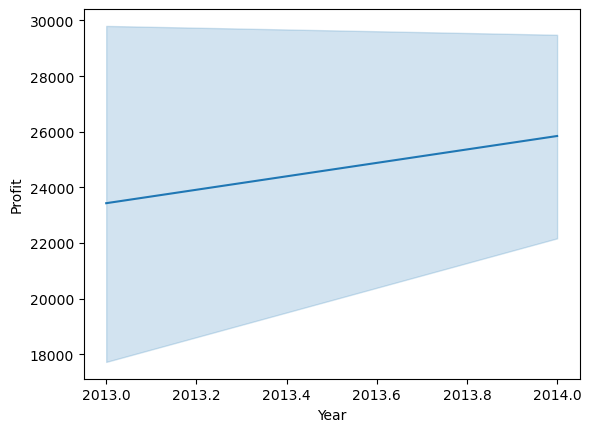

In [27]:
# Profit Trend by Year 
sns.lineplot(x='Year', y='Profit', data=df)


<Axes: xlabel='Discounts', ylabel='Sales'>

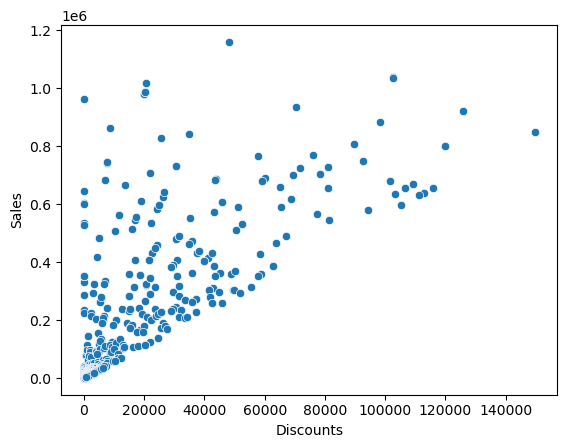

In [28]:
# Relationship between Discount and Sales 
sns.scatterplot(x='Discounts', y='Sales', data=df)


<Axes: xlabel='Sales', ylabel='Profit'>

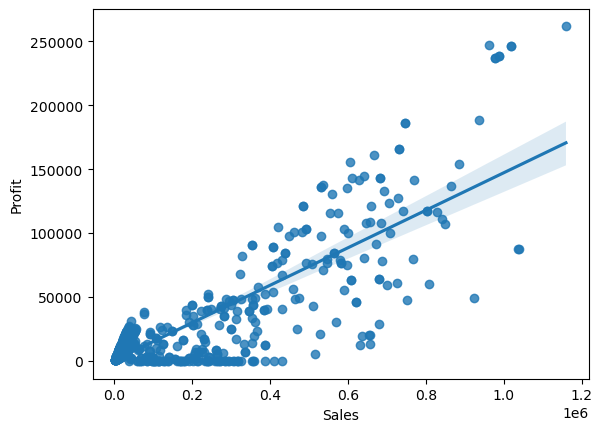

In [29]:
# Relationship Betwween Sales and Profit 
sns.regplot(x='Sales', y='Profit', data=df)


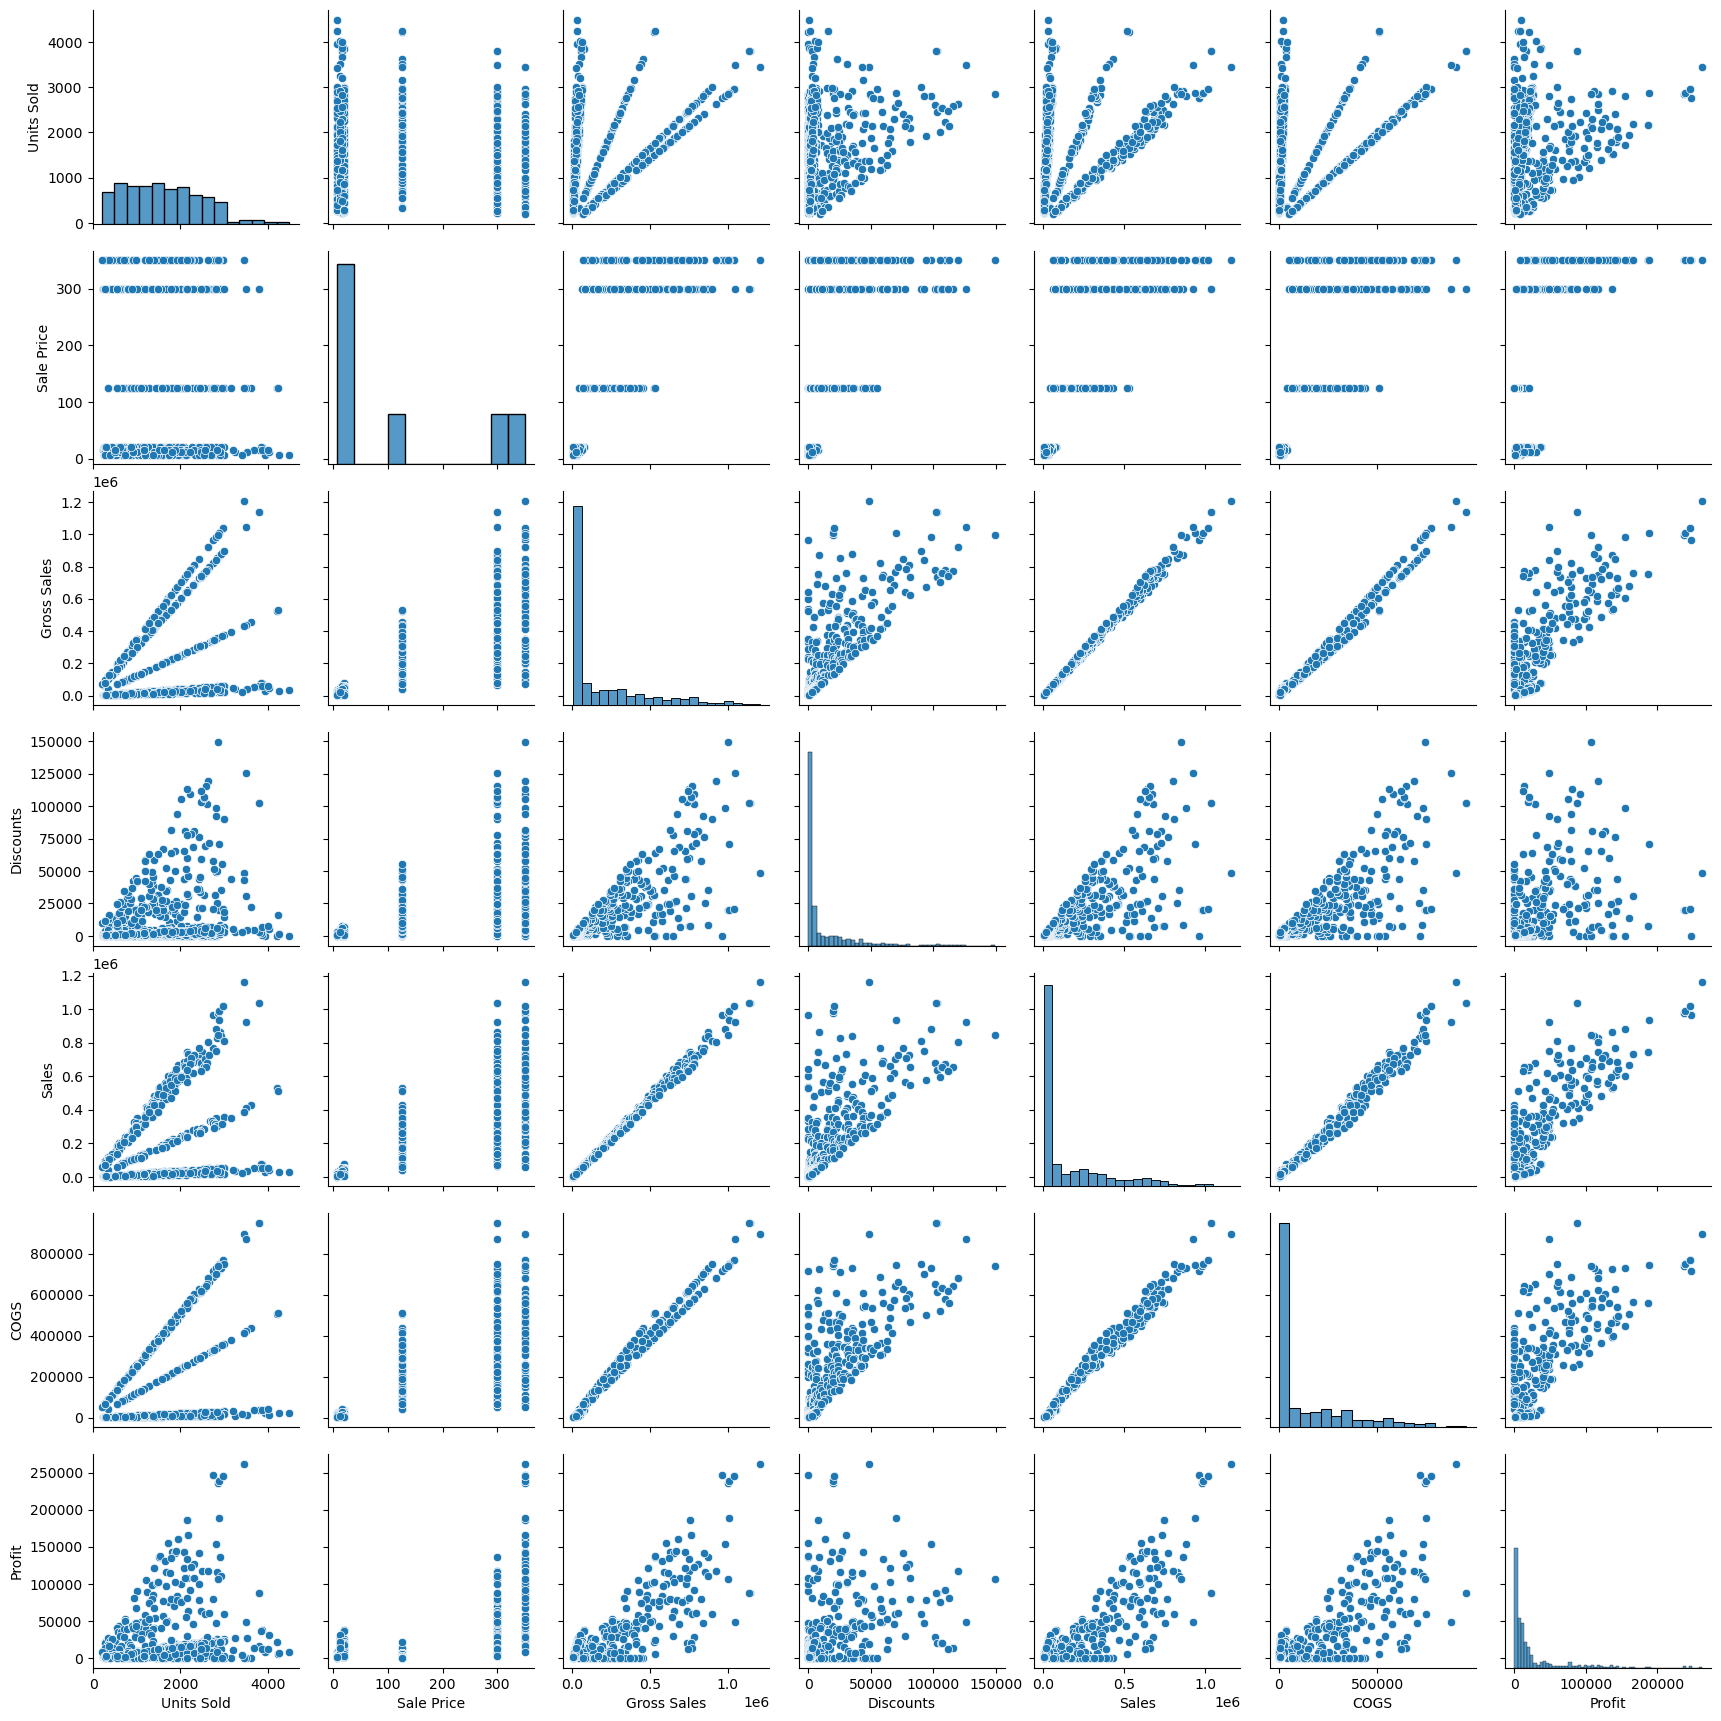

In [30]:
# Pairwise Relationships Between Key Metrics 
sns.pairplot(df[['Units Sold', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit']])


In [31]:
# Performig Predictive modelling- Simple Linear regression  
x=df[['COGS']]
y=df['Profit']

In [32]:
from sklearn.model_selection import train_test_split
x_train ,x_test ,y_train ,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(x_train , y_train)

LinearRegression()

In [34]:
y_pred = model.predict(x_test)


In [35]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MSE:', mse)
print('R² Score:', r2)


MSE: 836875800.9650525
R² Score: 0.6251672887491102


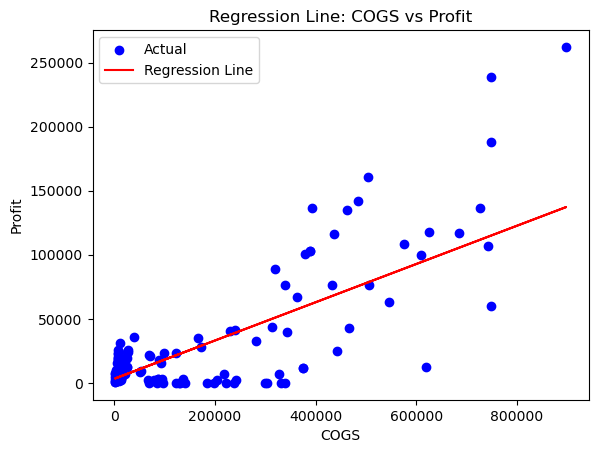

In [36]:
import matplotlib.pyplot as plt

# Scatter plot of actual data
plt.scatter(x_test, y_test, color='blue', label='Actual')

# Regression line
plt.plot(x_test, model.predict(x_test), color='red', label='Regression Line')

# Add labels and legend
plt.xlabel('COGS')
plt.ylabel('Profit')
plt.title('Regression Line: COGS vs Profit')
plt.legend()
plt.show()


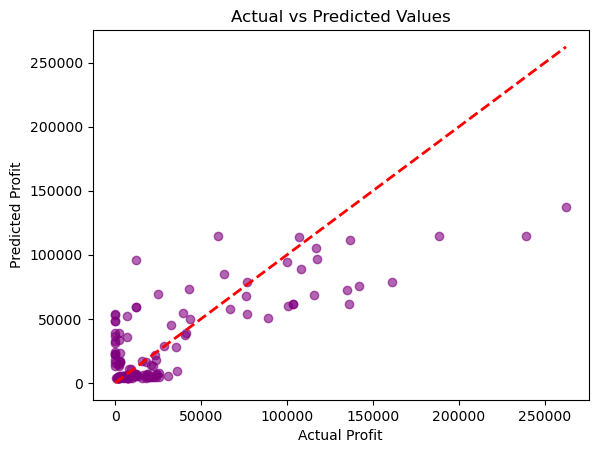

In [41]:
# Predict on test data
y_pred = model.predict(x_test)

# Scatter plot of actual vs predicted
plt.scatter(y_test, y_pred, color='purple', alpha=0.6)

# Add a 45-degree reference line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)

# Add labels and title
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Values')
plt.show()
